# EDA


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

%matplotlib inline

## Load data
Using AAPL, 5 years of daily bars.

In [59]:
# pull GOOGL from yfinance
df = yf.Ticker("GOOGL").history(period="5y", interval="1d", auto_adjust=False).reset_index()

# keep only 2024-2025
df = df[(df["Date"].dt.year >= 2024) & (df["Date"].dt.year <= 2025)].reset_index(drop=True)

print(df.shape)
df.head()

(502, 9)


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2024-01-02 00:00:00-05:00,138.550003,139.449997,136.479996,138.169998,137.037399,23711200,0.0,0.0
1,2024-01-03 00:00:00-05:00,137.250000,139.630005,137.080002,138.919998,137.781250,24212100,0.0,0.0
2,2024-01-04 00:00:00-05:00,138.419998,139.160004,136.350006,136.389999,135.271988,27137700,0.0,0.0
3,2024-01-05 00:00:00-05:00,136.750000,137.160004,135.149994,135.729996,134.617386,22513900,0.0,0.0
4,2024-01-08 00:00:00-05:00,136.289993,139.009995,136.259995,138.839996,137.701904,21404000,0.0,0.0


## Missing values
Want to see if any columns have NaN before we use them.

In [60]:
# count NaNs per column
df.isna().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

## Outlier check

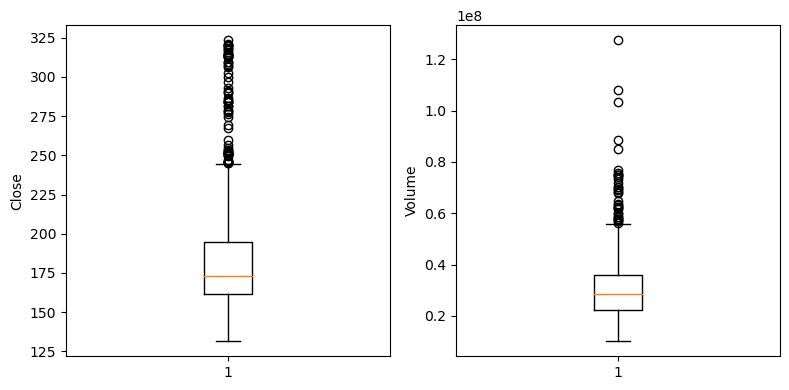

In [61]:
# box plots for close and volume
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].boxplot(df['Close'].dropna())
ax[0].set_ylabel('Close')
ax[1].boxplot(df['Volume'].dropna())
ax[1].set_ylabel('Volume')
plt.tight_layout()
plt.show()

## SMA crossover

In [62]:
# moving averages
df['SMA20'] = df['Close'].rolling(20).mean()
df['SMA50'] = df['Close'].rolling(50).mean()

# cross signal: +1 when SMA20 goes above SMA50, -1 when it goes below
above = (df['SMA20'] > df['SMA50']).astype(int)
df['SMA_Cross_Signal'] = above.diff().fillna(0).astype(int)
df.iloc[61:]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,SMA20,SMA50,SMA_Cross_Signal
61,2024-04-01 00:00:00-04:00,150.690002,155.740005,150.610001,155.490005,154.215424,31730800,0.0,0.0,143.365000,143.967201,0
62,2024-04-02 00:00:00-04:00,153.500000,154.699997,152.149994,154.559998,153.293030,24586000,0.0,0.0,144.425500,144.130801,1
63,2024-04-03 00:00:00-04:00,153.600006,155.080002,152.729996,154.919998,153.650085,24705000,0.0,0.0,145.538000,144.309401,0
64,2024-04-04 00:00:00-04:00,153.500000,154.770004,150.449997,150.529999,149.296066,34724700,0.0,0.0,146.494500,144.379201,0
65,2024-04-05 00:00:00-04:00,150.029999,153.419998,149.600006,152.500000,151.249924,23459200,0.0,0.0,147.400500,144.455201,0
...,...,...,...,...,...,...,...,...,...,...,...,...
497,2025-12-24 00:00:00-05:00,314.769989,315.079987,311.920013,314.089996,313.869049,10097400,0.0,0.0,313.071500,291.767800,0
498,2025-12-26 00:00:00-05:00,314.480011,315.089996,312.279999,313.510010,313.289459,10899000,0.0,0.0,312.749500,293.017401,0
499,2025-12-29 00:00:00-05:00,311.369995,314.019989,310.619995,313.559998,313.339417,19621800,0.0,0.0,312.418500,294.259400,0
500,2025-12-30 00:00:00-05:00,312.500000,316.950012,312.459991,313.850006,313.629242,17380900,0.0,0.0,312.366499,295.470400,0


In [63]:
# just show the rows where a crossover actually happened
df[df['SMA_Cross_Signal'] != 0][['Date', 'Close', 'SMA20', 'SMA50', 'SMA_Cross_Signal']]

,Date,Close,SMA20,SMA50,SMA_Cross_Signal
62,2024-04-02 00:00:00-04:00,154.559998,144.425500,144.130801,1
148,2024-08-05 00:00:00-04:00,159.250000,176.800999,177.860600,-1
194,2024-10-09 00:00:00-04:00,161.860001,162.411001,161.778200,1
285,2025-02-21 00:00:00-05:00,179.660004,191.176501,192.007800,-1
345,2025-05-19 00:00:00-04:00,166.539993,159.943002,159.047401,1


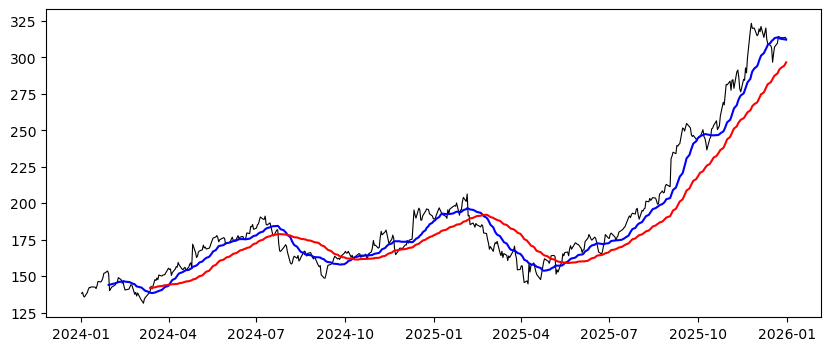

In [64]:
# plot price with SMA20 and SMA50, mark crossovers
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], color='black', linewidth=0.8)
plt.plot(df['Date'], df['SMA20'], color='blue')
plt.plot(df['Date'], df['SMA50'], color='red')

# green dots for golden cross, red for death cross
golden = df[df['SMA_Cross_Signal'] == 1]
death = df[df['SMA_Cross_Signal'] == -1]

## ATV slope

In [65]:
# 20-day average volume
df['Volume_SMA20'] = df['Volume'].rolling(20).mean()

# slope of the last 10 days of that average
df['ATV_Slope'] = df['Volume_SMA20'].rolling(10).apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0] if x.notna().all() else 0,
    raw=False)

# look at the last 15 rows
df[['Date', 'Volume', 'Volume_SMA20', 'ATV_Slope']].tail(15)

,Date,Volume,Volume_SMA20,ATV_Slope
487,2025-12-10 00:00:00-05:00,33428900,45992595.0,-2.207912e+04
488,2025-12-11 00:00:00-05:00,42353700,46868785.0,1.616875e+05
489,2025-12-12 00:00:00-05:00,35940200,47191095.0,2.038300e+05
490,2025-12-15 00:00:00-05:00,29151900,47066330.0,2.156867e+05
491,2025-12-16 00:00:00-05:00,30585000,45962070.0,1.603489e+05
492,2025-12-17 00:00:00-05:00,43930400,45700655.0,1.198237e+05
493,2025-12-18 00:00:00-05:00,33518000,43966610.0,-1.434936e+04
494,2025-12-19 00:00:00-05:00,59943200,43862510.0,-1.606140e+05
495,2025-12-22 00:00:00-05:00,26429900,41477120.0,-4.213471e+05
496,2025-12-23 00:00:00-05:00,25478700,38492800.0,-7.966261e+05


Text(0, 0.5, 'Volume')

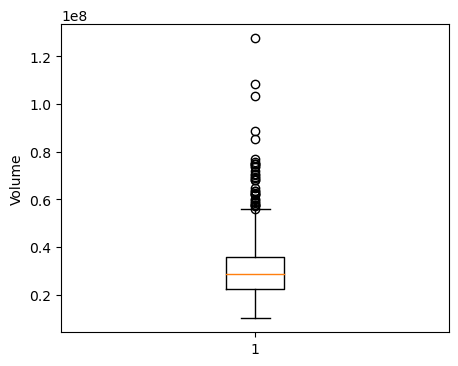

In [66]:
# volume has big spikes - box plot
plt.figure(figsize=(5, 4))
plt.boxplot(df['Volume'].dropna())
plt.ylabel('Volume')

## RSI (14-period)

In [71]:
# RSI formula
df['delta'] = df['Close'].diff()  # change in price

df['avg_gain'] = df['delta'].where(df['delta'] > 0, 0.0).rolling(14).mean()
df['avg_loss'] = (-df['delta'].where(df['delta'] < 0, 0.0)).rolling(14).mean()

df['RSI'] = 100 - (100 / (1 + df['avg_gain'] / df['avg_loss']))

# view last 15 rows including everything
df[['Date', 'Close', 'delta', 'avg_gain', 'avg_loss', 'RSI']].tail(15)

,Date,Close,delta,avg_gain,avg_loss,RSI
487,2025-12-10 00:00:00-05:00,320.209991,3.130005,3.507139,1.549997,69.350307
488,2025-12-11 00:00:00-05:00,312.429993,-7.779999,3.507139,1.865712,65.275198
489,2025-12-12 00:00:00-05:00,309.290009,-3.139984,2.777854,2.089996,57.065311
490,2025-12-15 00:00:00-05:00,308.220001,-1.070007,1.426426,2.166425,39.701789
491,2025-12-16 00:00:00-05:00,306.570007,-1.649994,1.079282,2.284282,32.087461
492,2025-12-17 00:00:00-05:00,296.720001,-9.850006,1.079282,2.738569,28.269368
493,2025-12-18 00:00:00-05:00,302.459991,5.739990,1.472855,2.738569,34.972844
494,2025-12-19 00:00:00-05:00,307.160004,4.700012,1.808570,2.360713,43.378434
495,2025-12-22 00:00:00-05:00,309.779999,2.619995,1.929999,2.360713,44.980855
496,2025-12-23 00:00:00-05:00,314.350006,4.570007,1.983571,2.360713,45.659322


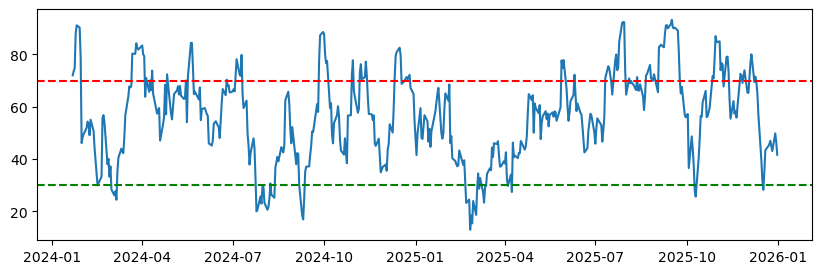

In [68]:
# plot RSI with 30/70 lines
plt.figure(figsize=(10, 3))
plt.plot(df['Date'], df['RSI'])
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

## Rule-based signal

In [69]:
# rule function copied from models.py
def generate_rule_signal(df, row_idx=-1):
    if df.empty or len(df) < 50:
        return "HOLD", {"reason": "insufficient_data"}
    if row_idx < 0:
        row_idx = len(df) + row_idx

    details = {}
    sma_cross = df['SMA_Cross_Signal'].iloc[row_idx]
    atv_slope = df['ATV_Slope'].iloc[row_idx]
    rsi = df['RSI'].iloc[row_idx]
    details['sma_cross'] = int(sma_cross)
    details['atv_slope'] = atv_slope
    details['rsi'] = rsi

    if sma_cross == 1:               # golden cross â†’ candidate BUY
        if atv_slope > 0:
            if rsi > 70:
                return "HOLD", details   # overbought, block buy
            return "BUY", details
        return "HOLD", details
    elif sma_cross == -1:            # death cross â†’ candidate SELL
        if atv_slope > 0:
            if rsi < 30:
                return "HOLD", details   # oversold, block sell
            return "SELL", details
        return "HOLD", details
    return "HOLD", details

In [70]:
# run the rule on every crossover day and collect the output
rows = []
for idx in df[df['SMA_Cross_Signal'] != 0].index:
    sig, det = generate_rule_signal(df, row_idx=idx)
    rows.append({
        'Date': df.loc[idx, 'Date'].date(),
        'Close': round(df.loc[idx, 'Close'], 2),
        'Cross': det['sma_cross'],
        'ATV_Slope': round(det['atv_slope'], 2) if pd.notna(det['atv_slope']) else None,
        'RSI': round(det['rsi'], 1) if pd.notna(det['rsi']) else None,
        'Signal': sig,
    })

pd.DataFrame(rows)

,Date,Close,Cross,ATV_Slope,RSI,Signal
0,2024-04-02,154.56,1,-588664.27,80.0,HOLD
1,2024-08-05,159.25,-1,574627.97,20.6,HOLD
2,2024-10-09,161.86,1,-389758.00,49.3,HOLD
3,2025-02-21,179.66,-1,-20026.61,23.2,HOLD
4,2025-05-19,166.54,1,456456.67,57.8,BUY


## Fundamentals — F-score inputs

The Piotroski F-score needs 9 data points from the annual statements (income, balance sheet, cash flow).
Before trusting them we need to check:
1. What yfinance actually returns (column names aren't consistent across tickers).
2. How often each input is NaN — this is what justifies the `elif … is None: score = 1` fallback branches in `calculate_piotroski_fscore`.

In [ ]:
# pull the 3 annual statements for GOOGL
# yfinance returns them with years as columns — transpose so rows are years
t = yf.Ticker("GOOGL")
inc = t.income_stmt.T.sort_index()
bs  = t.balance_sheet.T.sort_index()
cf  = t.cashflow.T.sort_index()

print("income_stmt   :", inc.shape)
print("balance_sheet :", bs.shape)
print("cashflow      :", cf.shape)
inc.head()

### Null check on the 9 F-score inputs (GOOGL)
For each input, grab the latest year's value and check if it's missing.

In [ ]:
# the 9 F-score inputs and which statement they live in, with name-variant fallbacks
FSCORE_INPUTS = {
    "Net Income":         (inc, ["Net Income", "NetIncome", "Net Income Common Stockholders"]),
    "Total Assets":       (bs,  ["Total Assets", "TotalAssets"]),
    "Operating CF":       (cf,  ["Operating Cash Flow", "Cash Flow From Continuing Operating Activities",
                                 "Total Cash From Operating Activities", "OperatingCashFlow"]),
    "Long Term Debt":     (bs,  ["Long Term Debt", "LongTermDebt", "Total Debt", "TotalDebt"]),
    "Current Assets":     (bs,  ["Current Assets", "CurrentAssets", "Total Current Assets"]),
    "Current Liab":       (bs,  ["Current Liabilities", "CurrentLiabilities", "Total Current Liabilities"]),
    "Shares":             (inc, ["Diluted Average Shares", "Basic Average Shares",
                                 "Shares Issued", "ShareIssued", "Ordinary Shares Number"]),
    "Gross Profit":       (inc, ["Gross Profit", "GrossProfit"]),
    "Revenue":            (inc, ["Total Revenue", "TotalRevenue", "Revenue"]),
}

def pick(df, candidates):
    # return (column_name_found, value) — matches _safe_val logic in models.py
    for c in candidates:
        if c in df.columns:
            v = df[c].iloc[-1]
            return c, (None if pd.isna(v) else v)
    return None, None

rows = []
for label, (d, cands) in FSCORE_INPUTS.items():
    col, val = pick(d, cands)
    rows.append({"input": label, "column_used": col, "value": val, "missing": val is None})
pd.DataFrame(rows)

### Column-name variations across tickers
yfinance doesn't always use the same label — e.g. some tickers return `Long Term Debt`, others only `Total Debt`, some have nothing at all. Checking a few large-caps confirms why `_safe_val` walks through a list of candidates instead of hard-coding one name.

In [ ]:
# which column-name variant is actually present for each ticker?
TICKERS = ["GOOGL", "AAPL", "MSFT", "JPM", "XOM", "KO"]

CANDIDATES = {
    "Net Income":     (("income", ["Net Income", "NetIncome", "Net Income Common Stockholders"])),
    "Long Term Debt": (("balance", ["Long Term Debt", "LongTermDebt", "Total Debt", "TotalDebt"])),
    "Operating CF":   (("cash",    ["Operating Cash Flow", "Cash Flow From Continuing Operating Activities",
                                    "Total Cash From Operating Activities", "OperatingCashFlow"])),
    "Shares":         (("income", ["Diluted Average Shares", "Basic Average Shares",
                                    "Shares Issued", "ShareIssued", "Ordinary Shares Number"])),
}

results = []
for tk in TICKERS:
    stock = yf.Ticker(tk)
    stmts = {"income": stock.income_stmt.T, "balance": stock.balance_sheet.T, "cash": stock.cashflow.T}
    row = {"ticker": tk}
    for label, (which, cands) in CANDIDATES.items():
        df_ = stmts[which]
        found = next((c for c in cands if c in df_.columns), "— MISSING —")
        row[label] = found
    results.append(row)

pd.DataFrame(results).set_index("ticker")

### Null coverage across tickers
Even when the column exists, the value can still be NaN (e.g. no long-term debt reported → debt rows absent; smaller filers sometimes omit gross profit). These NaNs are exactly why the F-score has "pass by default" branches — otherwise perfectly healthy firms would lose score points purely because yfinance didn't report a figure.

In [ ]:
# for each ticker × input, check whether the latest value is present
ALL_INPUTS = {
    "Net Income":     ("income",  ["Net Income", "NetIncome", "Net Income Common Stockholders"]),
    "Total Assets":   ("balance", ["Total Assets", "TotalAssets"]),
    "Operating CF":   ("cash",    ["Operating Cash Flow", "Cash Flow From Continuing Operating Activities",
                                    "Total Cash From Operating Activities", "OperatingCashFlow"]),
    "Long Term Debt": ("balance", ["Long Term Debt", "LongTermDebt", "Total Debt", "TotalDebt"]),
    "Current Assets": ("balance", ["Current Assets", "CurrentAssets", "Total Current Assets"]),
    "Current Liab":   ("balance", ["Current Liabilities", "CurrentLiabilities", "Total Current Liabilities"]),
    "Shares":         ("income",  ["Diluted Average Shares", "Basic Average Shares",
                                    "Shares Issued", "ShareIssued", "Ordinary Shares Number"]),
    "Gross Profit":   ("income",  ["Gross Profit", "GrossProfit"]),
    "Revenue":        ("income",  ["Total Revenue", "TotalRevenue", "Revenue"]),
}

matrix = []
for tk in TICKERS:
    stock = yf.Ticker(tk)
    stmts = {"income": stock.income_stmt.T, "balance": stock.balance_sheet.T, "cash": stock.cashflow.T}
    row = {"ticker": tk}
    for label, (which, cands) in ALL_INPUTS.items():
        df_ = stmts[which]
        _, val = pick(df_, cands)
        row[label] = "OK" if val is not None else "NaN"
    matrix.append(row)

pd.DataFrame(matrix).set_index("ticker")